In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# 1. Load the dataset
df = pd.read_csv('/content/drive/MyDrive/PROGRAMING/GHRISTU/sem4/micro project/heart_attack_prediction_dataset.csv')

In [9]:
# 2. View the first 5 rows to understand the structure
print("First 5 rows of HealthSync Data:")
display(df.head())

First 5 rows of HealthSync Data:


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [10]:
# 3. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype:

In [11]:
# 4. Initial Cleaning: Dropping unnecessary identifiers
# The 'Patient ID' won't help us predict heart attacks, so we drop it.
if 'Patient ID' in df.columns:
    df = df.drop(columns=['Patient ID'])

In [12]:
# 5. Handle Categorical Data (One-Hot Encoding)
# The 'Diet' column contains text (Healthy/Average/Unhealthy).
# We need to convert this into numbers for our AI model.
categorical_cols = ['Sex', 'Diet']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nData shape after encoding:", df_encoded.shape)
display(df_encoded.head())


Data shape after encoding: (8763, 26)


,Age,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sex_Male,Diet_Healthy,Diet_Unhealthy
0,67,208,158/88,72,0,0,1,0,0,4.168189,...,286,0,6,Argentina,South America,Southern Hemisphere,0,True,False,False
1,21,389,165/93,98,1,1,1,1,1,1.813242,...,235,1,7,Canada,North America,Northern Hemisphere,0,True,False,True
2,21,324,174/99,72,1,0,0,0,0,2.078353,...,587,4,4,France,Europe,Northern Hemisphere,0,False,True,False
3,84,383,163/100,73,1,1,1,0,1,9.828130,...,378,3,4,Canada,North America,Northern Hemisphere,0,True,False,False
4,66,318,91/88,93,1,1,1,1,0,5.804299,...,231,1,5,Thailand,Asia,Northern Hemisphere,0,True,False,True


Original shape: (8763, 25)
Cleaned shape: (8763, 24)


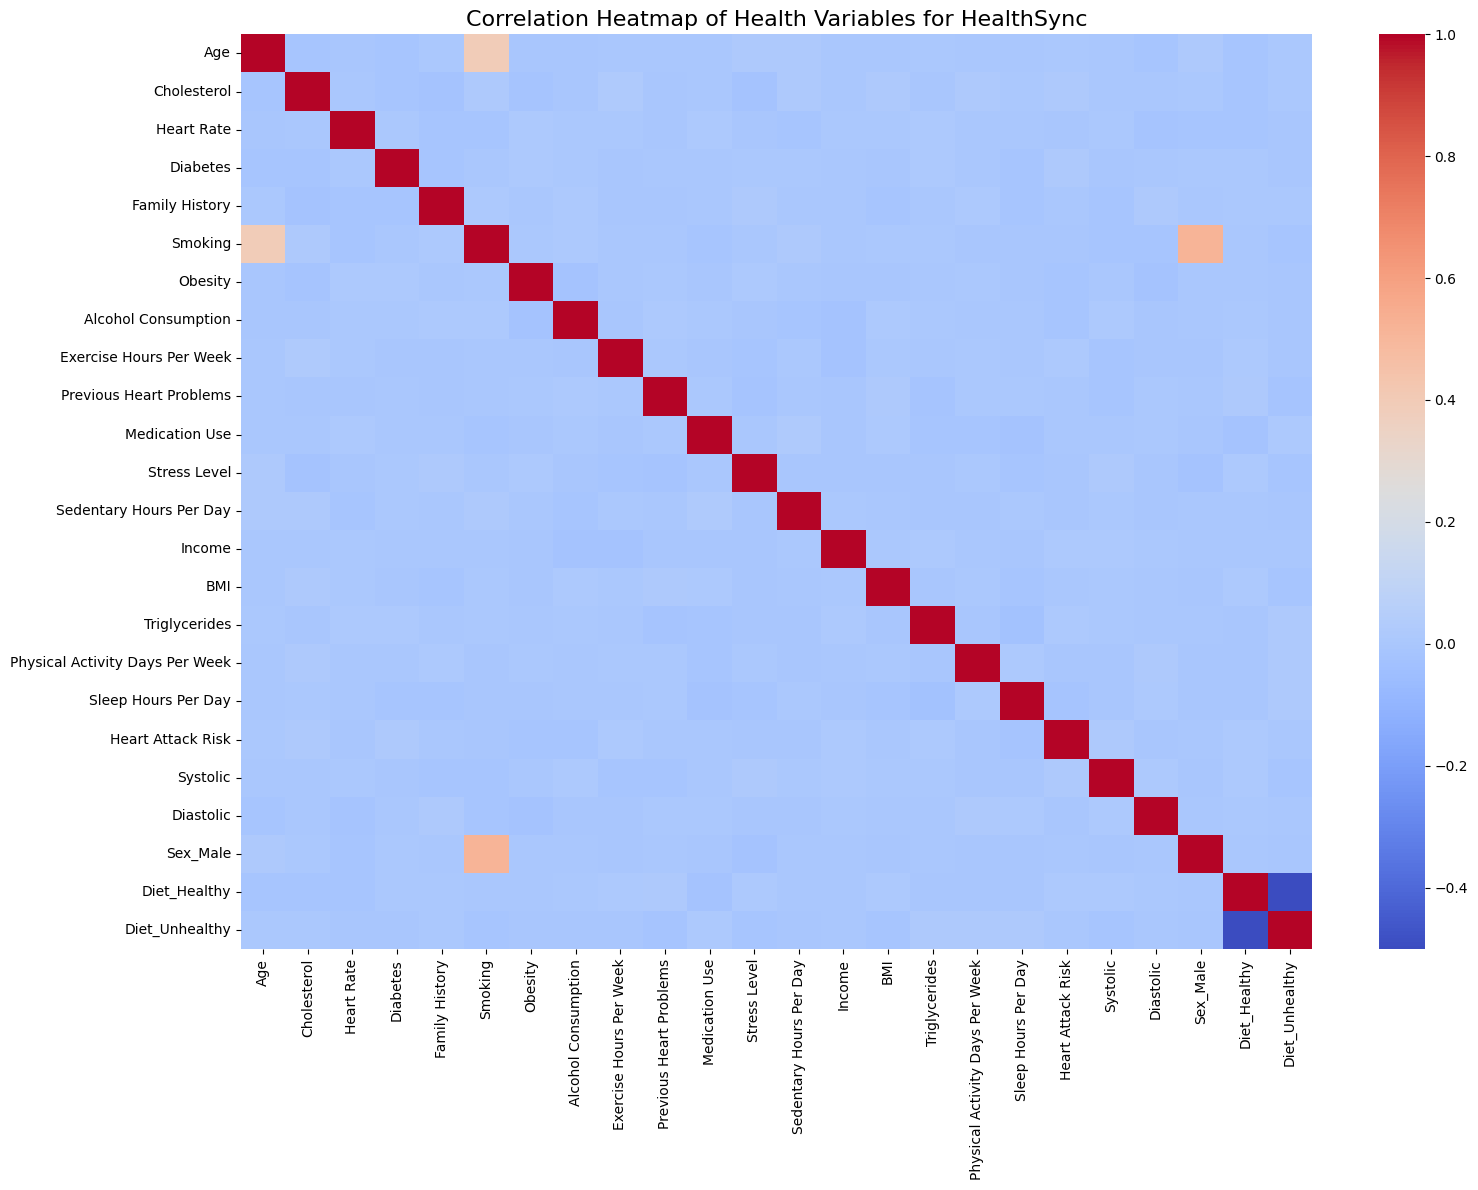


Top Correlations with Heart Attack Risk:

Heart Attack Risk          1.000000
Cholesterol                0.019340
Systolic                   0.018585
Diabetes                   0.017225
Exercise Hours Per Week    0.011133
Triglycerides              0.010471
Income                     0.009628
Diet_Healthy               0.009409
Age                        0.006403
Sex_Male                   0.003095
Name: Heart Attack Risk, dtype: float64


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Data Cleaning
print("Original shape:", df.shape)

# Drop columns that don't predict health (like Patient ID and Geography)
cols_to_drop = ['Patient ID', 'Country', 'Continent', 'Hemisphere']
df_cleaned = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Split 'Blood Pressure' (e.g., '120/80') into 'Systolic' and 'Diastolic' numbers
if 'Blood Pressure' in df_cleaned.columns:
    df_cleaned[['Systolic', 'Diastolic']] = df_cleaned['Blood Pressure'].str.split('/', expand=True).astype(float)
    df_cleaned = df_cleaned.drop(columns=['Blood Pressure'])

# One-Hot Encode categorical variables (Diet, Sex) into numbers (0s and 1s)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("Cleaned shape:", df_encoded.shape)

# 3. Exploratory Data Analysis (EDA) - Correlation Heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Health Variables for HealthSync', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Check specific correlations with Heart Attack Risk
print("\nTop Correlations with Heart Attack Risk:\n")
print(corr_matrix['Heart Attack Risk'].sort_values(ascending=False).head(10))

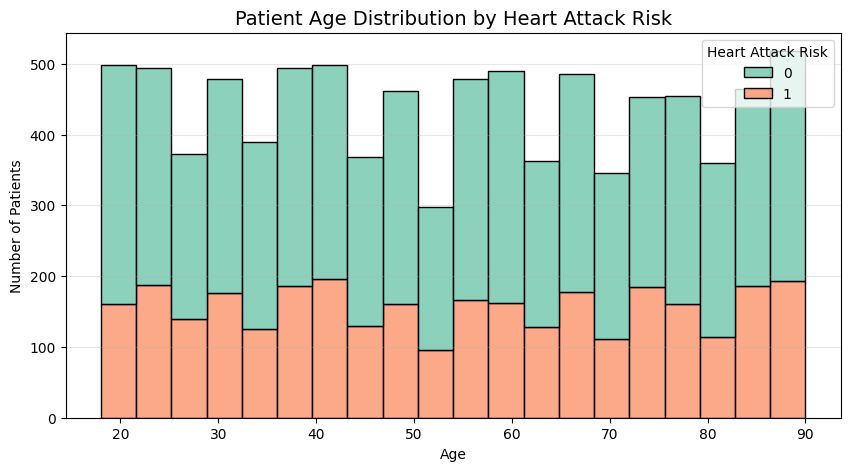

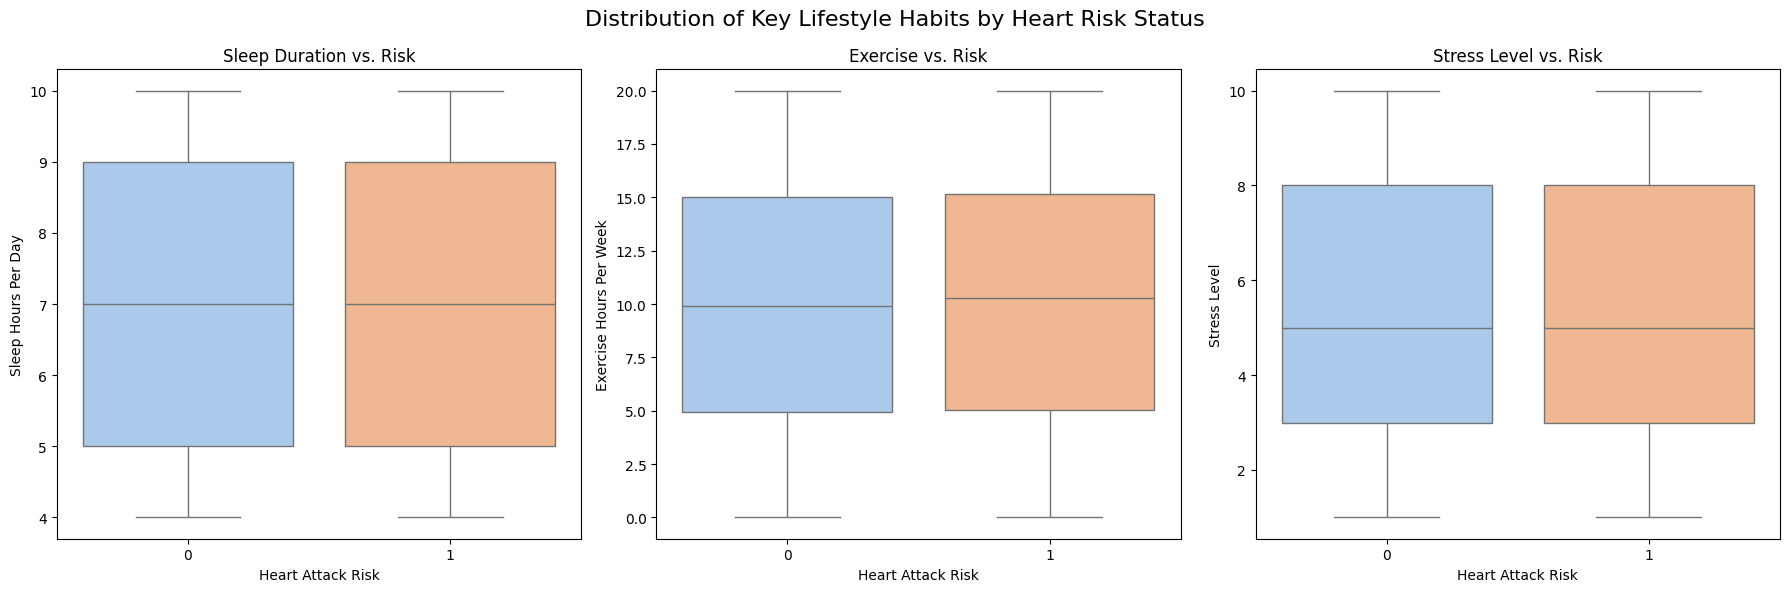

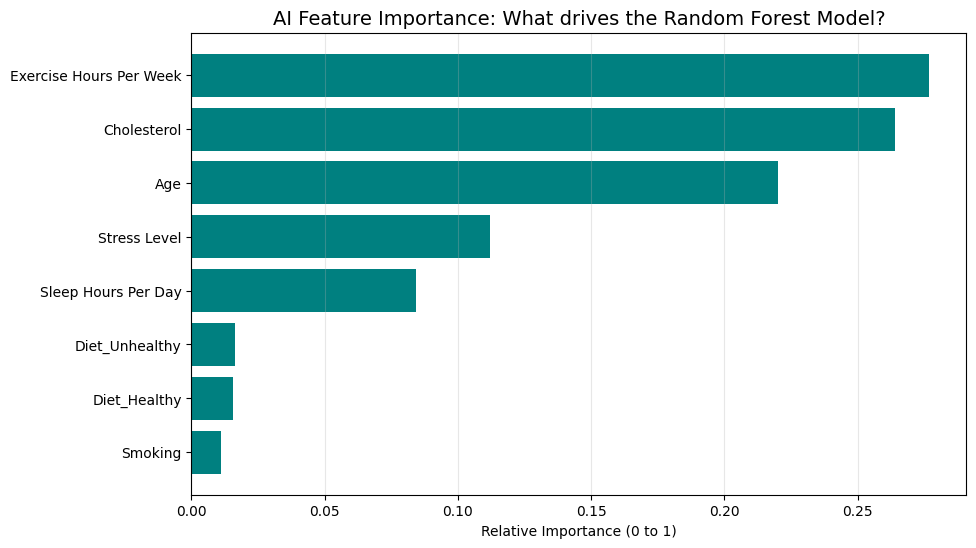

In [19]:
# We must One-Hot Encode the categorical variables so 'Diet_Healthy' exists
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

features_to_use = ['Age', 'Sleep Hours Per Day', 'Exercise Hours Per Week',
                   'Stress Level', 'Cholesterol', 'Smoking', 'Diet_Healthy', 'Diet_Unhealthy']

# Ensure column names match for Smoking
if 'Smoking_Yes' in df_encoded.columns:
    df_encoded = df_encoded.rename(columns={'Smoking_Yes': 'Smoking'})

# --- VISUALIZATION 1: Age Distribution by Risk ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df_encoded, x='Age', hue='Heart Attack Risk', multiple='stack', bins=20, palette='Set2')
plt.title('Patient Age Distribution by Heart Attack Risk', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- VISUALIZATION 2: The "Big 3" Lifestyle Factors (Boxplots) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Fix the FutureWarning by adding hue and setting legend=False
sns.boxplot(ax=axes[0], data=df_encoded, x='Heart Attack Risk', y='Sleep Hours Per Day', hue='Heart Attack Risk', palette='pastel', legend=False)
axes[0].set_title('Sleep Duration vs. Risk')

sns.boxplot(ax=axes[1], data=df_encoded, x='Heart Attack Risk', y='Exercise Hours Per Week', hue='Heart Attack Risk', palette='pastel', legend=False)
axes[1].set_title('Exercise vs. Risk')

sns.boxplot(ax=axes[2], data=df_encoded, x='Heart Attack Risk', y='Stress Level', hue='Heart Attack Risk', palette='pastel', legend=False)
axes[2].set_title('Stress Level vs. Risk')

plt.suptitle('Distribution of Key Lifestyle Habits by Heart Risk Status', fontsize=16)
plt.tight_layout()
plt.show()

# --- VISUALIZATION 3: AI Feature Importance ---
# Now this will work because df_encoded has the correct columns!
X_viz = df_encoded[features_to_use]
y_viz = df_encoded['Heart Attack Risk']

rf_viz = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_viz.fit(X_viz, y_viz)

# Extract and plot feature importances
importances = rf_viz.feature_importances_
feature_names = X_viz.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.title('AI Feature Importance: What drives the Random Forest Model?', fontsize=14)
plt.xlabel('Relative Importance (0 to 1)')
plt.grid(axis='x', alpha=0.3)
plt.show()

Training the Dashboard-Aligned AI...

Dashboard-Aligned Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      1125
           1       0.34      0.36      0.35       628

    accuracy                           0.51      1753
   macro avg       0.48      0.48      0.48      1753
weighted avg       0.52      0.51      0.52      1753



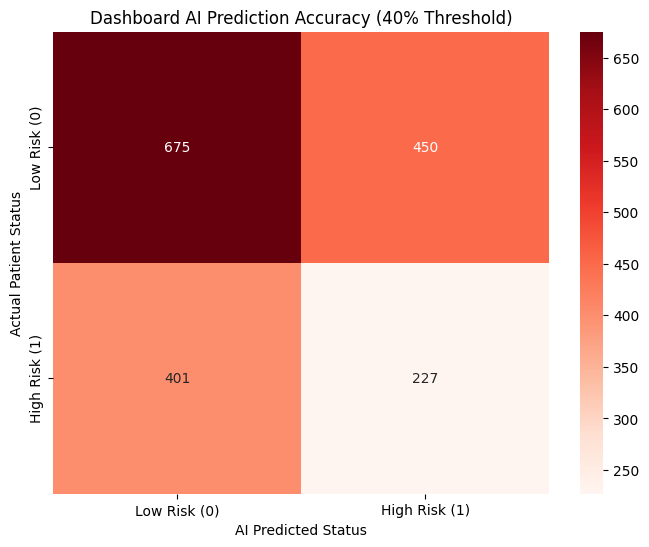

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select ONLY the lifestyle features used in the Dashboard
features_to_use = ['Age', 'Sleep Hours Per Day', 'Exercise Hours Per Week',
                   'Stress Level', 'Cholesterol', 'Smoking', 'Diet_Healthy', 'Diet_Unhealthy']

# Ensure column names match
if 'Smoking_Yes' in df_encoded.columns:
    df_encoded = df_encoded.rename(columns={'Smoking_Yes': 'Smoking'})

X = df_encoded[features_to_use]
y = df_encoded['Heart Attack Risk']

# 2. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the "Lifestyle-Only" Balanced Model
print("Training the Dashboard-Aligned AI...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 4. Use the 40% Probability Threshold (Same as app.py)
# Instead of a hard Yes/No, we get the percentage risk
y_probs = rf_model.predict_proba(X_test)[:, 1]

# If risk is >= 40%, flag as High Risk (1), else Low Risk (0)
y_pred_custom = (y_probs >= 0.40).astype(int)

# 5. Evaluate the Aligned Model
print("\nDashboard-Aligned Classification Report:")
print(classification_report(y_test, y_pred_custom))

# 6. Visualize the New Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Low Risk (0)', 'High Risk (1)'],
            yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.title('Dashboard AI Prediction Accuracy (40% Threshold)')
plt.ylabel('Actual Patient Status')
plt.xlabel('AI Predicted Status')
plt.show()

In [15]:
# !streamlit run /content/drive/MyDrive/PROGRAMING/GHRISTU/sem4/micro project/app.py &>/content/logs.txt &
# !npx localtunnel --port 8501